In [21]:
# This is a notebook to compare the Michaelis_Menten parameters generated from two sets of experimental data.
# This is done by constraining either Vmax or Km to be the same across both datasets while allowing the other parameter to differ. 
#Then, you can use the extra-sum-of-squares F-test on these models to determine if constraining each parameter individually significantly worsens the fit.

#Here's how you can modify the code to test for differences in each parameter separately:

#Testing Vmax
#1. Fit a model where Vmax is the same for both datasets but Km is different.
#2. Compare this model to the full model where both Vmax and Km are allowed to differ.
# Testing Km
#1. Fit a model where Km is the same for both datasets but Vmax is different.
#2. Compare this model to the full model where both Vmax and Km are allowed to differ.

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import f

# Define the Michaelis-Menten equation
def michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)

# Read experimental data from CSV file (modify as appropriate)
data = pd.read_csv('data\LDHInhib.csv')

# Extract the data columns (Modify as appropriate)
S = data['[Lactate]'].values
no_inhib = data['NoInhib'].values
comp = data['Comp'].values

# Fit the model to both datasets separately
popt1, _ = curve_fit(michaelis_menten, S, no_inhib, p0=[1, 1])
popt2, _ = curve_fit(michaelis_menten, S, comp, p0=[1, 1])

# Calculate the sum of squared residuals (SSR) for each fit
ssr1 = np.sum((no_inhib - michaelis_menten(S, *popt1))**2)
ssr2 = np.sum((comp - michaelis_menten(S, *popt2))**2)

# Combine the data
combined_S = np.concatenate([S, S])
combined_data = np.concatenate([no_inhib, comp])

# Full model: different parameters for each dataset
def full_model(S, Vmax1, Km1, Vmax2, Km2):
    return np.concatenate([
        michaelis_menten(S[:len(S)//2], Vmax1, Km1),
        michaelis_menten(S[len(S)//2:], Vmax2, Km2)
    ])

popt_full, _ = curve_fit(full_model, combined_S, combined_data, p0=[1, 1, 1, 1])
ssr_full = np.sum((combined_data - full_model(combined_S, *popt_full))**2)

# Reduced model for Vmax: same Vmax, different Km
def reduced_vmax_model(S, Vmax, Km1, Km2):
    return np.concatenate([
        michaelis_menten(S[:len(S)//2], Vmax, Km1),
        michaelis_menten(S[len(S)//2:], Vmax, Km2)
    ])

popt_reduced_vmax, _ = curve_fit(reduced_vmax_model, combined_S, combined_data, p0=[1, 1, 1])
ssr_reduced_vmax = np.sum((combined_data - reduced_vmax_model(combined_S, *popt_reduced_vmax))**2)

# Reduced model for Km: same Km, different Vmax
def reduced_km_model(S, Vmax1, Vmax2, Km):
    return np.concatenate([
        michaelis_menten(S[:len(S)//2], Vmax1, Km),
        michaelis_menten(S[len(S)//2:], Vmax2, Km)
    ])

popt_reduced_km, _ = curve_fit(reduced_km_model, combined_S, combined_data, p0=[1, 1, 1])
ssr_reduced_km = np.sum((combined_data - reduced_km_model(combined_S, *popt_reduced_km))**2)

# Calculate degrees of freedom
n = len(combined_data)
p_full = len(popt_full)
p_reduced_vmax = len(popt_reduced_vmax)
p_reduced_km = len(popt_reduced_km)
dfn_vmax = p_full - p_reduced_vmax  # Degrees of freedom numerator for Vmax
dfn_km = p_full - p_reduced_km      # Degrees of freedom numerator for Km
dfd = n - p_full                    # Degrees of freedom denominator

# Calculate the F-statistic for Vmax
f_stat_vmax = ((ssr_reduced_vmax - ssr_full) / dfn_vmax) / (ssr_full / dfd)

# Calculate the F-statistic for Km
f_stat_km = ((ssr_reduced_km - ssr_full) / dfn_km) / (ssr_full / dfd)

# Calculate the critical value from the F-distribution
alpha = 0.05  # Significance level
f_crit = f.ppf(1 - alpha, dfn_vmax, dfd)

# Print results for Vmax
print(f"SSR reduced model (Vmax): {ssr_reduced_vmax:.4f}")
print(f"SSR full model: {ssr_full:.4f}")
print(f"F-statistic (Vmax): {f_stat_vmax:.4f}")
print(f"Critical F-value: {f_crit:.4f}")

if f_stat_vmax > f_crit:
    print("Vmax is significantly different between the two datasets.")
else:
    print("Vmax is not significantly different between the two datasets.")

# Calculate the critical value from the F-distribution for Km
f_crit = f.ppf(1 - alpha, dfn_km, dfd)

# Print results for Km
print(f"SSR reduced model (Km): {ssr_reduced_km:.4f}")
print(f"SSR full model: {ssr_full:.4f}")
print(f"F-statistic (Km): {f_stat_km:.4f}")
print(f"Critical F-value: {f_crit:.4f}")

if f_stat_km > f_crit:
    print("Km is significantly different between the two datasets.")
else:
    print("Km is not significantly different between the two datasets.")


SSR reduced model (Vmax): 50.9828
SSR full model: 50.4367
F-statistic (Vmax): 0.5414
Critical F-value: 4.0343
Vmax is not significantly different between the two datasets.
SSR reduced model (Km): 69.1918
SSR full model: 50.4367
F-statistic (Km): 18.5927
Critical F-value: 4.0343
Km is significantly different between the two datasets.


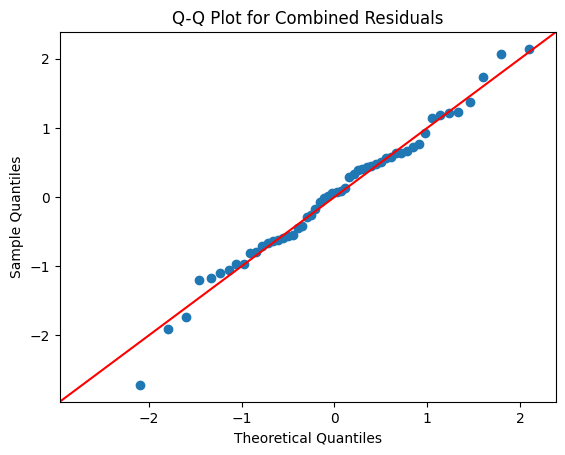

Shapiro-Wilk test statistic: 0.9883599271753236, p-value: 0.8770751066422003
Residuals are normally distributed (p-value > 0.05).


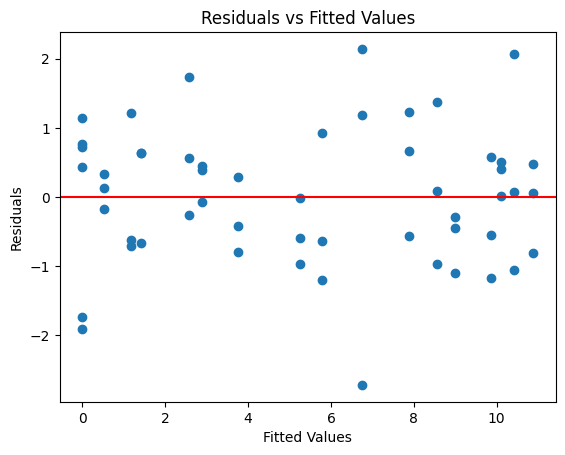

Breusch-Pagan test p-value: 0.8942700210621705
Residuals have constant variance (p-value > 0.05).


In [29]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

# Define the Michaelis-Menten equation
def michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)

# Read experimental data from CSV file
data = pd.read_csv('data\LDHInhib.csv')

# Extract the data columns
S = data['[Lactate]'].values
no_inhib = data['NoInhib'].values
comp = data['Comp'].values

# Fit the model to both datasets separately
popt1, _ = curve_fit(michaelis_menten, S, no_inhib, p0=[1, 1])
popt2, _ = curve_fit(michaelis_menten, S, comp, p0=[1, 1])

# Calculate residuals
residuals1 = no_inhib - michaelis_menten(S, *popt1)
residuals2 = comp - michaelis_menten(S, *popt2)

# Combine residuals
combined_residuals = np.concatenate([residuals1, residuals2])

# Check for normality of residuals
sm.qqplot(combined_residuals, line ='45')
plt.title('Q-Q Plot for Combined Residuals')
plt.show()

# Perform Shapiro-Wilk test for normality
shapiro_test = shapiro(combined_residuals)
print(f'Shapiro-Wilk test statistic: {shapiro_test.statistic}, p-value: {shapiro_test.pvalue}')

# Interpretation
if shapiro_test.pvalue > 0.05:
    print("Residuals are normally distributed (p-value > 0.05).")
else:
    print("Residuals are not normally distributed (p-value <= 0.05).")

# Plot residuals versus fitted values to check for homoscedasticity
fitted_values1 = michaelis_menten(S, *popt1)
fitted_values2 = michaelis_menten(S, *popt2)
combined_fitted_values = np.concatenate([fitted_values1, fitted_values2])

plt.scatter(combined_fitted_values, combined_residuals)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

# Perform Breusch-Pagan test for homoscedasticity
_, pval, _, _ = het_breuschpagan(combined_residuals, sm.add_constant(combined_fitted_values))


# Example output from the Breusch-Pagan test
print(f'Breusch-Pagan test p-value: {pval}')
# Interpretation
if pval > 0.05:
    print("Residuals have constant variance (p-value > 0.05).")
else:
    print("Residuals do not have constant variance (p-value <= 0.05).")
